# Giant donut profiles and wavefront fits, intra against extra focal (v2)

**Author:** Aaron Roodman
**Date Created:** 2026-10-05

Radial and azimuthal flux profiles of the 8 mm giant donuts on both sides of
focus, on the near-on-axis sensor R22_S10, testing whether the ring of excess flux
Josh sees in extra-focal donuts is a pupil-model (mask boundary) effect or an
optical path difference (OPD) effect such as a turned-down edge on the inside of
M1.

Then the same two donuts fitted with ts_wep's blitz forward model in four
configurations -- the v3.14 and v1000 pupil models, each with spider shadows off
and on -- with each fit's model image profiled the same way as the data and
overlaid on it.

Part of item 7 of `notes/todos/todo-ideas.md`. Settled inputs and the state of the
investigation are in `notes/status/item7_giant_donuts_handoff.md`; the superseded
geometry work is `wfs/docs/giant_donuts_pupil_findings.md`.

## What this notebook is for

The two hypotheses make different predictions, which is what makes the radial
profile a discriminator rather than a description:

| | mask boundary error | OPD error (turned-down M1 inner edge) |
|---|---|---|
| where | at the pupil edge | smooth, weighted to the pupil edge |
| flux | conserved on each side of the edge | redistributed **across** the edge |
| intra against extra | same sign | **reverses sign** |
| pupil model | radius differs v3.14 against v1000 | unchanged by the pupil model |

So the diagnostic is the **intra minus extra difference** of the normalised
profile, not either profile alone.

## Geometry this rests on

Traced on-axis through the full system with batoid, the surviving pupil annulus is

| model | inner edge | outer edge |
|---|---|---|
| v3.14 | 2.5580 m | 4.1796 m (M1 rim) |
| v1000 | 2.5840 m | 4.1650 m (M1 baffles) |

The inner edge is M1's inner radius in both, and it moves **outward by 26.0 mm**
from v3.14 to v1000 — the same place a turned-down M1 inner edge would act. The
v1000 outer edge is set by the new M1 baffles, 15 mm inside M1's unchanged rim.


## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Binning](#binning)
6. [Analysis: radial profiles](#analysis)
7. [Results & Plots](#results)
8. [Azimuthal profiles](#azimuthal)
9. [Wavefront fits: two pupil models, spiders off and on](#fits)
10. [Residual images](#residuals)
11. [Interpretation](#interpretation)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================
butler_repo = "/repo/main"
raw_collection = "LSSTCam/raw/all"
instrument = "LSSTCam"

# day_obs 20251023, BLOCK-T626, r band, 60 s. The defocus is a symmetric
# 4 + 4 mm split: +/-4000 um on the M2 hexapod (Trim dof0) and +/-4000 um on the
# camera hexapod (Trim dof5), against the in-focus seq_num 336. Established
# label-independently from the Trim -- see the handoff.
EXPOSURES = {
    "extra": 2025102300337,   # extra_8mm, Bryce's pair
    "intra": 2025102300340,   # intra_8mm, Bryce's pair
}

# Near-on-axis science sensor (field radius 0.235 deg), per item 7 Q6 and Aaron's
# note that Bryce found a good isolated donut here. R22_S11 is exactly on-axis if
# a second sensor is wanted; R30_S21 at 1.695 deg is what the archived notebook used.
detector_name = "R22_S10"

# Stamp half-size, in pixels. Measured on this data the giant donut is about
# 695 pixels across, i.e. a radius of about 347 pixels, so the stamp must be
# comfortably larger than that or the profile is cut off before the outer edge.
stamp_half_pix = 430

# Radial and azimuthal binning. Both come from rp, where the convergence scans
# that set them are documented; the Binning section below reproduces those scans.
# Radial is 1.5 pixel per bin, azimuthal 1.0 deg -- fine enough to resolve the
# 9.0 pixel edge roll-off and the 0.86 deg spider vanes respectively.
radial_bin_pix = 1.5
n_radial_bins = int(round(stamp_half_pix / radial_bin_pix))

# The annulus the azimuthal profile averages over, as a fraction of the outer
# edge. It excludes both edges so the profile is not dominated by roll-off or by
# a small centring error.
azimuthal_bin_deg = 1.0
n_azimuthal_bins = int(round(360.0 / azimuthal_bin_deg))
azimuthal_annulus = (0.65, 0.95)

# Pupil radius, in meters, used only to state the angular scale the
# azimuthal binning has to resolve.
instrument_radius_m = 4.18

# Fit configurations: the 2x2 of pupil model against spider modelling.
FIT_CONFIGS = [
    ("v3.14", False), ("v3.14", True),
    ("v1000", False), ("v1000", True),
]

# Blur FWHM upper bound, in arcsec. blitz hardcodes 5.0, which lets the blur
# absorb real wavefront error; 1.5 is near the seeing on this night. The fits
# report whether they landed on the bound.
fwhm_max_arcsec = 1.5

# least_squares tolerance. blitz defaults to 1e-3, which stops a giant-donut
# fit after about 5 function evaluations.
fit_tol = 1e-8

# ts_wep checkout carrying the blitz prototype. The shared checkout is on
# `develop`, which has no blitz subpackage.
fit_blitz_python = "/sdf/home/r/roodman/u/LSST/packages/ts_wep_blitz/python"

# Generated v1000 maskParams, from gen_mask_params.py.
mask_params_v1000 = "../../output/giant_donuts/maskParams_v1000.yaml"

output_dir = "../../output/giant_donuts"


<a id='setup'></a>
## Setup & Imports

In [2]:
import logging
import os
import sys
from pathlib import Path

# Topic directory is the nearest parent holding a code/ dir; the repo root is its
# parent. Both must go on sys.path before any repo import, so `common` and this
# study's modules are importable.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                      # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code' / 'giant_donuts'))   # this study

import numpy as np
import matplotlib.pyplot as plt

import lsst.daf.butler as dafButler
from lsst.obs.lsst import LsstCam

from common.utils import setup_plotting

import radial_profile as rp
import donut_images as di
import fit_giant_donut as fg

# IsrTask logs a dozen INFO lines per exposure, which buries the printed
# results; the warning about the r_57 zero point is expected and harmless.
logging.getLogger('lsst.isr').setLevel(logging.WARNING)

setup_plotting()
camera = LsstCam.getCamera()
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Fail loudly if the notebook's bin sizes drift from the module's documented
# choices, rather than silently producing differently-binned numbers.
assert radial_bin_pix == rp.RADIAL_BIN_PIX, (radial_bin_pix, rp.RADIAL_BIN_PIX)
assert azimuthal_bin_deg == rp.AZIMUTHAL_BIN_DEG, (
    azimuthal_bin_deg, rp.AZIMUTHAL_BIN_DEG)
print(f"radial {radial_bin_pix} pixel per bin -> {n_radial_bins} bins")
print(f"azimuthal {azimuthal_bin_deg} deg per bin -> {n_azimuthal_bins} bins")


radial 1.5 pixel per bin -> 287 bins
azimuthal 1.0 deg per bin -> 360 bins


<a id='functions'></a>
## Helper Functions

Minimal instrument signature removal (ISR) and sky handling, following the
archived `wfs_giant_donut_fit.ipynb`: the giant-donut exposures carry no donut
tables and no pipeline fits, so the stamps are cut from the raw here.

Note the item's reference to `common/camera_utils.py` for `pixel_to_focal` is
stale — that module does not exist, and the archived notebook defined the helper
inline. The camera geometry API is used directly instead.

In [3]:
# ISR, donut finding, stamp cutting and field angles come from the study's
# donut_images module, so the notebook and fit_giant_donut.py work from pixels
# reduced identically.
help(di.minimal_isr_config)


Help on function minimal_isr_config in module donut_images:

minimal_isr_config()
    `lsst.ip.isr.IsrTaskConfig` doing overscan, assembly and gains only.

    Returns
    -------
    config : `lsst.ip.isr.IsrTaskConfig`
        Configuration with every calibration-product step disabled.



<a id='data'></a>
## Data Access

Read the raw, run minimal ISR, and locate the donut. The donut position has to be
found rather than assumed: there are no donut tables for these exposures.

In [4]:
butler = dafButler.Butler(butler_repo)

images = {}
for side, exposure in EXPOSURES.items():
    images[side] = di.run_isr(butler, exposure, detector_name, camera,
                              raw_collection, instrument)
    print(f"{side:>5}  exposure {exposure}  {detector_name}  "
          f"shape {images[side].shape}  "
          f"median {np.median(images[side]):.1f} electrons/pixel")


extra  exposure 2025102300337  R22_S10  shape (4004, 4096)  median 2094.0 electrons/pixel


intra  exposure 2025102300340  R22_S10  shape (4004, 4096)  median 2212.7 electrons/pixel


In [5]:
positions = {}
for side, image in images.items():
    x_pix, y_pix, diameter, area = di.find_donut(image)
    ax_deg, ay_deg = di.field_angle_deg(detector_name, x_pix, y_pix, camera)
    positions[side] = (x_pix, y_pix)
    print(f"{side:>5}  donut at pixel ({x_pix:.0f}, {y_pix:.0f})  "
          f"diameter {diameter} pixel "
          f"({diameter * di.PIXEL_SIZE_M * 1e3:.2f} mm)  "
          f"area {area} pixel  "
          f"field angle ({ax_deg:+.3f}, {ay_deg:+.3f}) deg")
print("\nFor reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm "
      "camera-plus-M2\nsplit and 7.0 mm for camera-only 8 mm.")


extra  donut at pixel (1534, 898)  diameter 695 pixel (6.95 mm)  area 232065 pixel  field angle (-0.263, -0.061) deg


intra  donut at pixel (1536, 890)  diameter 685 pixel (6.85 mm)  area 230738 pixel  field angle (-0.263, -0.062) deg

For reference, wfs/ predicted a 6.7 mm donut span for a 4 + 4 mm camera-plus-M2
split and 7.0 mm for camera-only 8 mm.


Inspect the stamps before profiling them. The donut must be
isolated and unsaturated, and the ring Josh describes should be visible by eye in
the extra-focal stamp if it is as strong as reported.

Text(0.5, 0.98, 'Giant donuts, R22_S10, 4 + 4 mm hexapod split')

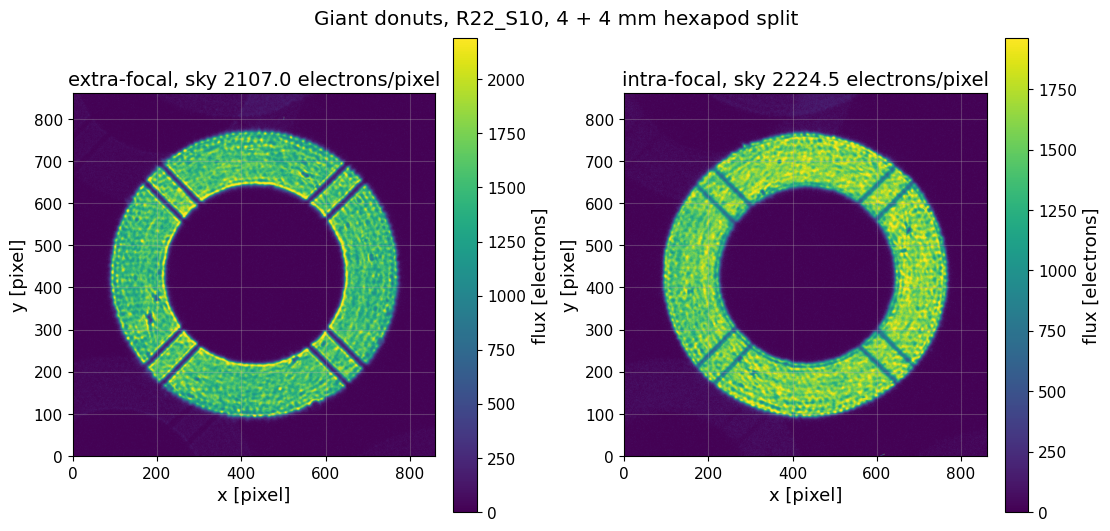

In [6]:
stamps = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
for ax, (side, image) in zip(axes, images.items()):
    stamp, sky = di.cut_stamp(image, *positions[side], half=stamp_half_pix)
    stamps[side] = stamp
    if stamp is None:
        ax.set_title(f"{side}: stamp off detector")
        continue
    vmax = np.nanpercentile(stamp, 99.5)
    im = ax.imshow(stamp, origin="lower", vmin=0, vmax=vmax, cmap="viridis")
    ax.set_title(f"{side}-focal, sky {sky:.1f} electrons/pixel")
    ax.set_xlabel("x [pixel]")
    ax.set_ylabel("y [pixel]")
    fig.colorbar(im, ax=ax, label="flux [electrons]")
fig.suptitle(f"Giant donuts, {detector_name}, 4 + 4 mm hexapod split")


<a id='binning'></a>
## Binning

Both profiles are **resolution-limited, not noise-limited**: at one pixel per
radial bin the signal-to-noise per bin is already of order 1000, so shrinking
bins costs almost nothing in noise and the only question is whether a bin is
coarse enough to average a feature away.

The scans below choose the bin sizes by measuring where the features stop
changing. Two statistics:

- **amplitude** — the feature's measured size. Too-coarse bins average it down,
  so it rises as bins shrink, then plateaus. The plateau is the answer.
- **lag-1 autocorrelation** — whether neighbouring bins track the same feature.
  Negative means oversmoothed. Rising through 0.5–0.7 means resolved.
  Saturating toward 1.0 means the curve is already resolved and extra bins just
  subdivide it.

The radial scan is below. The azimuthal scan needs the fitted outer
edge, so it sits at the top of the Azimuthal profiles section.


In [7]:
for side, stamp in stamps.items():
    if stamp is None:
        continue
    print(f"--- {side}-focal, radial ---")
    print(f"{'bins':>6} {'pix/bin':>8} {'ring zone':>10} {'edge width':>11} "
          f"{'med err':>9}")
    for row in rp.bin_convergence(stamp, kind='radial'):
        print(f"{row['n_bins']:>6} {row['bin_size']:>8.2f} "
              f"{row['amplitude']:>10.4f} {row['edge_width']:>8.1f} pix "
              f"{row['median_err']:>9.5f}")

print(f"\nChosen: {rp.RADIAL_BIN_PIX} pixel per bin ({n_radial_bins} bins).")
print("Two things converge by this width and not before. The ring-zone mean "
      "settles\nnear 0.86 (intra) and 1.00 (extra); at 2.15 pixel per bin it "
      "reads about 12 per\ncent high, and at 3.6 pixel per bin it collapses "
      "and mislocates the peak to the\nouter edge. The outer-edge roll-off "
      "width also stops shrinking here.")
print("\nThe lag-1 autocorrelation is not shown for the radial profile: it "
      "exceeds 0.98\nat every bin width, because a smooth monotonic curve "
      "always correlates between\nneighbouring bins. It is diagnostic "
      "azimuthally, where the structure is not\nmonotonic.")


--- extra-focal, radial ---
  bins  pix/bin  ring zone  edge width   med err


    80     5.38     1.0161     15.9 pix   0.00233
   120     3.59     0.9561     14.2 pix   0.00285
   172     2.50     0.9778     12.4 pix   0.00337
   200     2.15     1.0163     12.8 pix   0.00366
   286     1.51     0.9959     13.4 pix   0.00436
   430     1.00     1.0030     12.9 pix   0.00542
   860     0.50     0.9952     12.9 pix   0.00751
--- intra-focal, radial ---
  bins  pix/bin  ring zone  edge width   med err


    80     5.38     0.8836     42.9 pix   0.00229
   120     3.59     0.9025     35.8 pix   0.00277
   172     2.50     0.8402     10.0 pix   0.00332
   200     2.15     0.8632     38.6 pix   0.00354
   286     1.51     0.8595     39.0 pix   0.00429
   430     1.00     0.8691      9.0 pix   0.00523
   860     0.50     0.8583      9.0 pix   0.00722

Chosen: 1.5 pixel per bin (287 bins).
Two things converge by this width and not before. The ring-zone mean settles
near 0.86 (intra) and 1.00 (extra); at 2.15 pixel per bin it reads about 12 per
cent high, and at 3.6 pixel per bin it collapses and mislocates the peak to the
outer edge. The outer-edge roll-off width also stops shrinking here.

The lag-1 autocorrelation is not shown for the radial profile: it exceeds 0.98
at every bin width, because a smooth monotonic curve always correlates between
neighbouring bins. It is diagnostic azimuthally, where the structure is not
monotonic.


<a id='analysis'></a>
## Analysis

Radial profiles, normalised so radius is 1.0 at the fitted outer edge and flux has
unit mean over the illuminated annulus. Both normalisations are needed before the
two sides can be compared: the intra and extra donuts differ in size and in total
flux for reasons that have nothing to do with the ring.

In [8]:
profiles = {}
for side, stamp in stamps.items():
    if stamp is None:
        continue
    r_pix, flux, flux_err, n_pix = rp.radial_profile(stamp, n_bins=n_radial_bins)
    r_norm, flux_norm, r_edge_pix = rp.normalise_profile(r_pix, flux)
    profiles[side] = dict(r_pix=r_pix, flux=flux, flux_err=flux_err,
                          r_norm=r_norm, flux_norm=flux_norm,
                          r_edge_pix=r_edge_pix)
    print(f"{side:>5}  fitted outer edge {r_edge_pix:.1f} pixel  "
          f"({r_edge_pix * 10e-3:.2f} mm at the 10 um pixel)")


extra  fitted outer edge 341.5 pixel  (3.42 mm at the 10 um pixel)


intra  fitted outer edge 335.7 pixel  (3.36 mm at the 10 um pixel)


In [9]:
# Ring excess at the inner edge, per side and per pupil model's inner radius.
# Referenced to a local baseline further out in the annulus, so it measures the
# ring rather than the step from the central hole.
print(f"{'side':>6}  {'model':>6}  {'edge_norm':>10}  {'ring_excess':>12}")
for side, prof in profiles.items():
    for model, edge_norm in rp.INNER_EDGE_NORM.items():
        excess = rp.ring_excess(prof["r_norm"], prof["flux_norm"], edge_norm)
        print(f"{side:>6}  {model:>6}  {edge_norm:>10.4f}  {excess:>+12.4f}")
print("\nring_excess is dimensionless: normalised flux in the band just outside "
      "the\ninner edge minus the local baseline further out in the annulus.")


  side   model   edge_norm   ring_excess
 extra   v3.14      0.6120       -0.0626
 extra   v1000      0.6204       +0.0132
 intra   v3.14      0.6120       -0.3120
 intra   v1000      0.6204       -0.2106

ring_excess is dimensionless: normalised flux in the band just outside the
inner edge minus the local baseline further out in the annulus.


In [10]:
# Zone statistics: the quantitative form of the diagnostic.
#
# The inner ring zone sits just outside the inner pupil edge, the outer zone just
# inside the rim. An OPD term moves flux between them in opposite directions on
# the two sides of focus; a mask boundary error would instead move an edge
# position the same way on both sides.
ZONES = {"inner ring": (0.62, 0.70), "outer": (0.94, 1.00)}

print(f"{'zone':<12} {'range':>12} {'extra':>9} {'intra':>9} {'extra-intra':>12}")
for name, (lo, hi) in ZONES.items():
    means = {}
    for side, prof in profiles.items():
        sel = (np.isfinite(prof["flux_norm"]) & (prof["r_norm"] >= lo)
               & (prof["r_norm"] < hi))
        means[side] = float(np.mean(prof["flux_norm"][sel])) if sel.any() else np.nan
    difference = means.get("extra", np.nan) - means.get("intra", np.nan)
    print(f"{name:<12} {f'{lo:.2f}-{hi:.2f}':>12} {means.get('extra', np.nan):>9.4f} "
          f"{means.get('intra', np.nan):>9.4f} {difference:>+12.4f}")
print("\nAll values are normalised flux, dimensionless, relative to the mean over "
      "the\nilluminated annulus.")


zone                range     extra     intra  extra-intra
inner ring      0.62-0.70    1.0073    0.8532      +0.1541
outer           0.94-1.00    0.8803    0.9760      -0.0957

All values are normalised flux, dimensionless, relative to the mean over the
illuminated annulus.


<a id='results'></a>
## Results & Plots

The top panel is the two normalised profiles. The bottom panel is the diagnostic:
intra minus extra. A **mask boundary** error gives a narrow feature at the edges
whose position shifts with the pupil model. An **OPD** error such as a turned-down
M1 inner edge gives a feature at the inner edge that **reverses sign** between the
two sides, with a compensating deficit beside it.

largest intra-minus-extra difference -0.3330 (dimensionless) at normalised radius 0.648


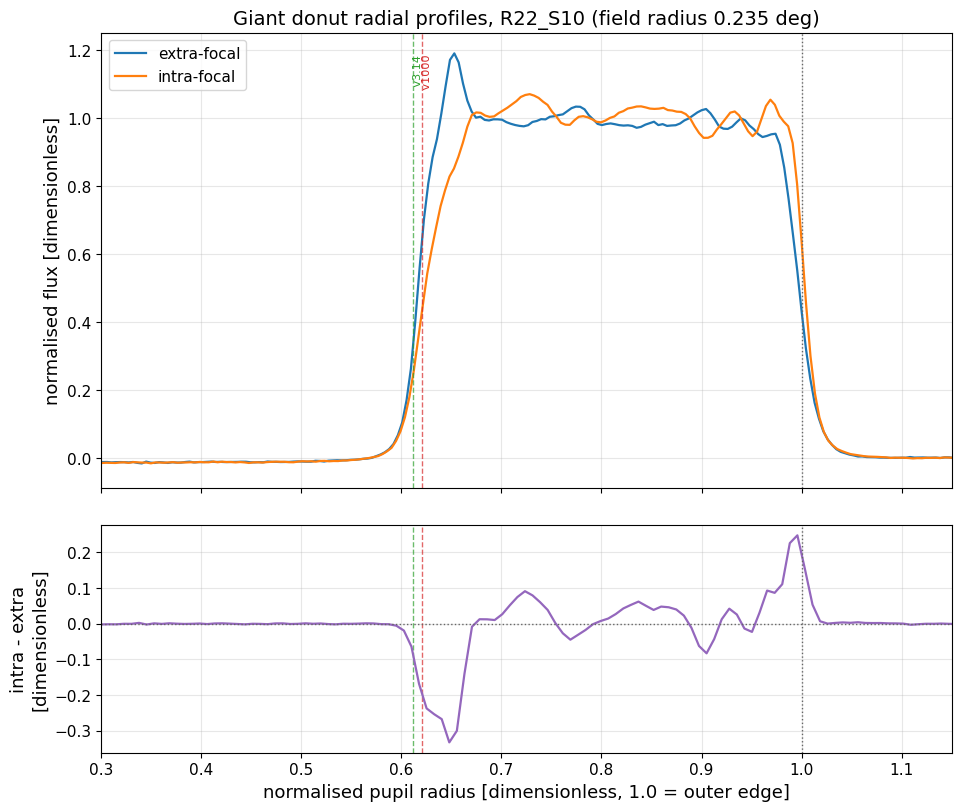

In [11]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(9.5, 8), sharex=True,
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for side, prof in profiles.items():
    ax_top.plot(prof["r_norm"], prof["flux_norm"], lw=1.6, label=f"{side}-focal")

for model, edge_norm in rp.INNER_EDGE_NORM.items():
    for ax in (ax_top, ax_bot):
        ax.axvline(edge_norm, ls="--", lw=1.0, alpha=0.7,
                   color="C2" if model == "v3.14" else "C3")
    ax_top.text(edge_norm, ax_top.get_ylim()[1] * 0.95, f" {model}",
                rotation=90, va="top", fontsize=8,
                color="C2" if model == "v3.14" else "C3")

ax_top.axvline(1.0, ls=":", lw=1.0, color="0.4")
ax_top.set_ylabel("normalised flux [dimensionless]")
ax_top.legend(loc="upper left")
ax_top.set_title(f"Giant donut radial profiles, {detector_name} "
                 f"(field radius 0.235 deg)")

if {"intra", "extra"} <= set(profiles):
    r_grid, difference = rp.profile_difference(
        profiles["intra"]["r_norm"], profiles["intra"]["flux_norm"],
        profiles["extra"]["r_norm"], profiles["extra"]["flux_norm"])
    ax_bot.plot(r_grid, difference, lw=1.6, color="C4")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    ax_bot.axvline(1.0, ls=":", lw=1.0, color="0.4")
    peak = int(np.nanargmax(np.abs(difference)))
    print(f"largest intra-minus-extra difference {difference[peak]:+.4f} "
          f"(dimensionless) at normalised radius {r_grid[peak]:.3f}")

ax_bot.set_xlabel("normalised pupil radius [dimensionless, 1.0 = outer edge]")
ax_bot.set_ylabel("intra - extra\n[dimensionless]")
ax_bot.set_xlim(0.3, 1.15)
fig.savefig(f"{output_dir}/radial_profiles_{detector_name}.pdf",
            bbox_inches="tight")


<a id='azimuthal'></a>
## Azimuthal profiles

The radial profile averages over azimuth, so it dilutes anything localised. This
is the complementary cut: average over radius within an annulus that excludes
both edges, and look at the variation with angle.

Two features are expected and should be told apart. The **spiders** give narrow,
regularly spaced dips at the same azimuth on both sides of focus. A **localised
figure error** gives a broader modulation at one azimuth and, being an OPD term,
should reverse sign between intra and extra.

In [12]:
for side, stamp in stamps.items():
    if stamp is None:
        continue
    print(f"--- {side}-focal, azimuthal ---")
    print(f"{'bins':>6} {'deg/bin':>8} {'peak-to-peak':>13} {'med err':>9} "
          f"{'p2p/err':>8} {'autocorr':>9}")
    for row in rp.bin_convergence(stamp, kind='azimuthal',
                                  r_edge_pix=profiles[side]['r_edge_pix'],
                                  r_range_norm=azimuthal_annulus):
        ratio = row['amplitude'] / row['median_err'] if row['median_err'] else np.nan
        print(f"{row['n_bins']:>6} {row['bin_size']:>8.2f} "
              f"{row['amplitude']:>13.4f} {row['median_err']:>9.5f} "
              f"{ratio:>8.0f} {row['autocorr']:>9.3f}")

vane_deg = np.degrees(2 * np.arcsin(rp.SPIDER_WIDTH_M / 2
                                    / (0.8 * instrument_radius_m)))
print(f"\nA {rp.SPIDER_WIDTH_M} m spider vane at 0.8 of the pupil radius subtends "
      f"{vane_deg:.2f} deg, so\nthe 5 deg bins this study started with washed the "
      f"vanes out entirely.")
print(f"Chosen: {rp.AZIMUTHAL_BIN_DEG} deg per bin ({n_azimuthal_bins} bins), where "
      f"the autocorrelation shows\nthe structure is resolved and p2p/err is near "
      f"its maximum.")

--- extra-focal, azimuthal ---
  bins  deg/bin  peak-to-peak   med err  p2p/err  autocorr


    72     5.00        0.4392   0.00290      151    -0.213
   120     3.00        0.5721   0.00367      156     0.037
   180     2.00        0.7600   0.00450      169     0.225
   240     1.50        0.8675   0.00515      169     0.425
   360     1.00        0.9177   0.00623      147     0.671
   480     0.75        0.9380   0.00718      131     0.794
   720     0.50        0.9889   0.00873      113     0.899
  1080     0.33        1.0136   0.01066       95     0.952
--- intra-focal, azimuthal ---
  bins  deg/bin  peak-to-peak   med err  p2p/err  autocorr


    72     5.00        0.2632   0.00256      103     0.076
   120     3.00        0.3702   0.00318      116     0.374
   180     2.00        0.4528   0.00388      117     0.475
   240     1.50        0.5082   0.00444      115     0.633
   360     1.00        0.5229   0.00536       98     0.787
   480     0.75        0.5377   0.00622       86     0.865
   720     0.50        0.5593   0.00760       74     0.933
  1080     0.33        0.5649   0.00928       61     0.966

A 0.05 m spider vane at 0.8 of the pupil radius subtends 0.86 deg, so
the 5 deg bins this study started with washed the vanes out entirely.
Chosen: 1.0 deg per bin (360 bins), where the autocorrelation shows
the structure is resolved and p2p/err is near its maximum.


In [13]:
azimuthal = {}
for side, stamp in stamps.items():
    if stamp is None:
        continue
    angle_deg, flux, flux_err, n_pix = rp.azimuthal_profile(
        stamp, n_bins=n_azimuthal_bins, r_range_norm=azimuthal_annulus,
        r_edge_pix=profiles[side]["r_edge_pix"])
    # Normalise to unit mean so the two sides are comparable in shape.
    scale = np.nanmean(flux)
    azimuthal[side] = dict(angle_deg=angle_deg, flux_norm=flux / scale,
                           flux_err_norm=flux_err / scale, n_pix=n_pix)
    finite = np.isfinite(flux)
    print(f"{side:>5}  {int(finite.sum())} of {n_azimuthal_bins} bins populated, "
          f"median {int(np.median(n_pix))} pixel per bin, "
          f"peak-to-peak {np.nanmax(flux / scale) - np.nanmin(flux / scale):.4f} "
          f"(dimensionless)")

extra  360 of 360 bins populated, median 489 pixel per bin, peak-to-peak 0.9177 (dimensionless)
intra  360 of 360 bins populated, median 472 pixel per bin, peak-to-peak 0.5229 (dimensionless)


largest intra-minus-extra azimuthal difference +0.5219 (dimensionless) at 140.5 deg
robust scatter of the difference 0.0491 (dimensionless)


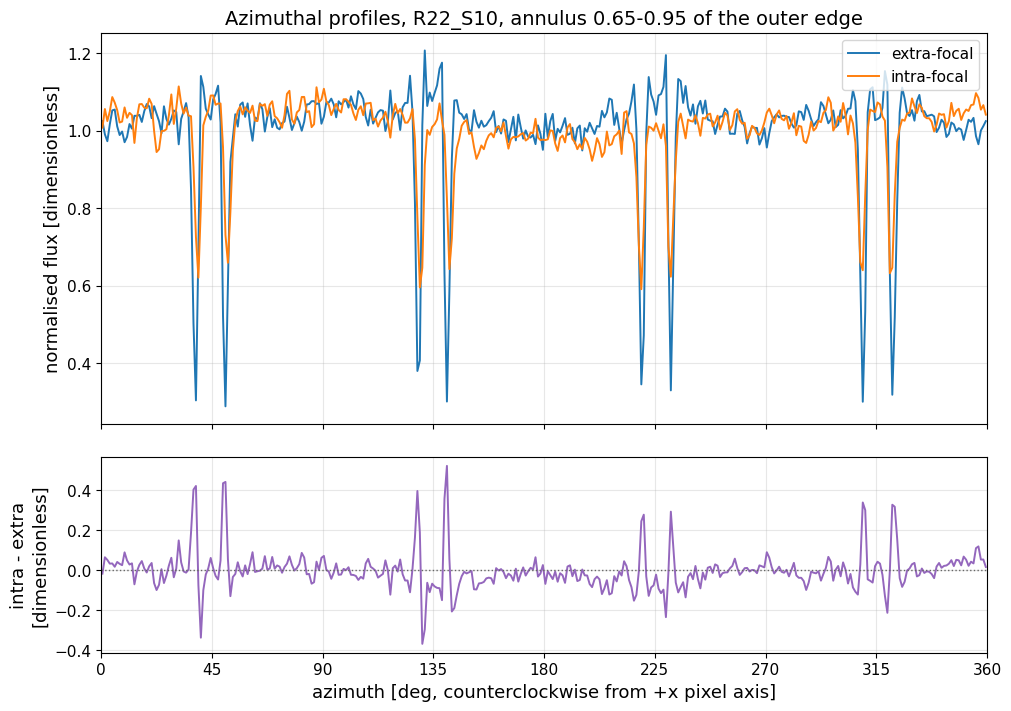

In [14]:
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True,
    gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for side, prof in azimuthal.items():
    ax_top.plot(prof["angle_deg"], prof["flux_norm"], lw=1.4, label=f"{side}-focal")

ax_top.set_ylabel("normalised flux [dimensionless]")
ax_top.legend(loc="upper right")
ax_top.set_title(f"Azimuthal profiles, {detector_name}, annulus "
                 f"{azimuthal_annulus[0]:.2f}-{azimuthal_annulus[1]:.2f} "
                 f"of the outer edge")

if {"intra", "extra"} <= set(azimuthal):
    difference = azimuthal["intra"]["flux_norm"] - azimuthal["extra"]["flux_norm"]
    ax_bot.plot(azimuthal["intra"]["angle_deg"], difference, lw=1.4, color="C4")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    peak = int(np.nanargmax(np.abs(difference)))
    print(f"largest intra-minus-extra azimuthal difference "
          f"{difference[peak]:+.4f} (dimensionless) at "
          f"{azimuthal['intra']['angle_deg'][peak]:.1f} deg")
    print(f"robust scatter of the difference "
          f"{1.48 * np.nanmedian(np.abs(difference - np.nanmedian(difference))):.4f} "
          f"(dimensionless)")

ax_bot.set_xlabel("azimuth [deg, counterclockwise from +x pixel axis]")
ax_bot.set_ylabel("intra - extra\n[dimensionless]")
ax_bot.set_xlim(0, 360)
ax_bot.set_xticks(np.arange(0, 361, 45))
fig.savefig(f"{output_dir}/azimuthal_profiles_{detector_name}.pdf",
            bbox_inches="tight")

<a id='fits'></a>
## Wavefront fits: two pupil models, spiders off and on

Fits use blitz's own danish factory and forward model, driven directly rather
than through the butler pipeline — this engineering night has no reference
catalog or matched calibrations, and the question is about the forward model.

The defocus is the measured 4 + 4 mm split: 4.0 mm on the camera hexapod and
4.0 mm on M2, signed positive extra-focal.

`maskParams` alone does not change the pupil model. blitz carries the pupil
twice — the analytic mask danish uses *and* a batoid telescope supplying the
reference wavefront — so `fg.pupil_override` swaps both together.

In [15]:
# _import_blitz repairs the frozen lsst.ts namespace path, so this works
# even though lsst.daf.butler was imported above. It verifies that blitz
# AND its ts_wep siblings all come from this checkout.
blitz_utils, wf_task = fg._import_blitz(fit_blitz_python)
print("blitz from", blitz_utils.__file__)

fits = {}
for model_name, spiders in FIT_CONFIGS:
    fg.pupil_override(
        blitz_utils, model_name,
        mask_params_file=(mask_params_v1000 if model_name == "v1000" else None))

    for side, stamp in stamps.items():
        if stamp is None:
            continue
        sign = +1.0 if side == "extra" else -1.0
        offsets = tuple(sign * o for o in fg.EXTRA_OFFSETS_M)
        x_pix, y_pix = positions[side]
        ax_deg, ay_deg = di.field_angle_deg(detector_name, x_pix, y_pix, camera)

        fits[(model_name, spiders, side)] = fg.fit_stamp(
            stamp, np.deg2rad(ax_deg), np.deg2rad(ay_deg), offsets,
            blitz_utils, wf_task, fwhm_max=fwhm_max_arcsec,
            spiders=spiders, tol=fit_tol, max_nfev=300)

print(f"{len(fits)} fits done: {len(FIT_CONFIGS)} configurations "
      f"x {len(stamps)} sides")

blitz from /sdf/home/r/roodman/u/LSST/packages/ts_wep_blitz/python/lsst/ts/wep/blitz/utils.py


8 fits done: 4 configurations x 2 sides


In [16]:
# The 2x2, and the Z11 split that item 7 is about.
print(f"{'model':7s} {'spiders':8s} {'chi2/dof extra':>15s} {'chi2/dof intra':>15s} "
      f"{'Z11 split':>11s}")
print(f"{'':16s}{'[dof ' + str(fits[(FIT_CONFIGS[0][0], FIT_CONFIGS[0][1], 'extra')]['dof']) + ']':>15s}"
      f"{'':15s}{'[um wf]':>12s}")
for model_name, spiders in FIT_CONFIGS:
    e = fits[(model_name, spiders, "extra")]
    i = fits[(model_name, spiders, "intra")]
    split = i["zk_dev_um"][fg.NOLL_Z11] - e["zk_dev_um"][fg.NOLL_Z11]
    print(f"{model_name:7s} {'on' if spiders else 'off':8s} "
          f"{e['chi2_per_dof']:>15.3f} {i['chi2_per_dof']:>15.3f} {split:>+11.4f}")

print("\nZ11 split is intra minus extra, in um of wavefront. The data show about "
      "0.30 um,\nof which diffraction accounts for about 0.10 um.")

print(f"\n{'model':7s} {'spiders':8s} {'side':>6s} {'blur FWHM':>11s} {'at bound':>9s}")
for model_name, spiders in FIT_CONFIGS:
    for side in ("extra", "intra"):
        f = fits[(model_name, spiders, side)]
        print(f"{model_name:7s} {'on' if spiders else 'off':8s} {side:>6s} "
              f"{f['fwhm_arcsec']:>8.3f} as {'yes' if f['fwhm_at_bound'] else 'no':>9s}")
print(f"\nBlur bound is 0.1 to {fwhm_max_arcsec} arcsec. A fit on the bound has not "
      f"measured the blur.")

model   spiders   chi2/dof extra  chi2/dof intra   Z11 split
                   [dof 184015]                    [um wf]
v3.14   off               14.994           7.132     +0.8037
v3.14   on                12.004           6.033     +0.7838
v1000   off               14.891           7.141     +0.3669
v1000   on                11.819           6.017     +0.3511

Z11 split is intra minus extra, in um of wavefront. The data show about 0.30 um,
of which diffraction accounts for about 0.10 um.

model   spiders    side   blur FWHM  at bound
v3.14   off       extra    1.008 as        no
v3.14   off       intra    1.500 as       yes
v3.14   on        extra    0.986 as        no
v3.14   on        intra    1.500 as       yes
v1000   off       extra    1.017 as        no
v1000   off       intra    1.500 as       yes
v1000   on        extra    0.984 as        no
v1000   on        intra    1.500 as       yes

Blur bound is 0.1 to 1.5 arcsec. A fit on the bound has not measured the blur.


### Fit overlays on the radial profiles

Each fit's model image is profiled exactly as the data was, then overlaid.
Separate panels per side of focus, because the two sides are different
measurements and overplotting them hides which model fails where.

The model images are on the binned grid, so they are compared in normalised
radius rather than pixels.

model   spiders    side   nMAD resid
v3.14   off       extra       0.0239
v3.14   off       intra       0.0283
v3.14   on        extra       0.0262
v3.14   on        intra       0.0290
v1000   off       extra       0.0232
v1000   off       intra       0.0261
v1000   on        extra       0.0282
v1000   on        intra       0.0261

nMAD of the data-minus-model normalised flux over the flat annulus 0.65-0.95,
dimensionless. Lower is a better radial match.


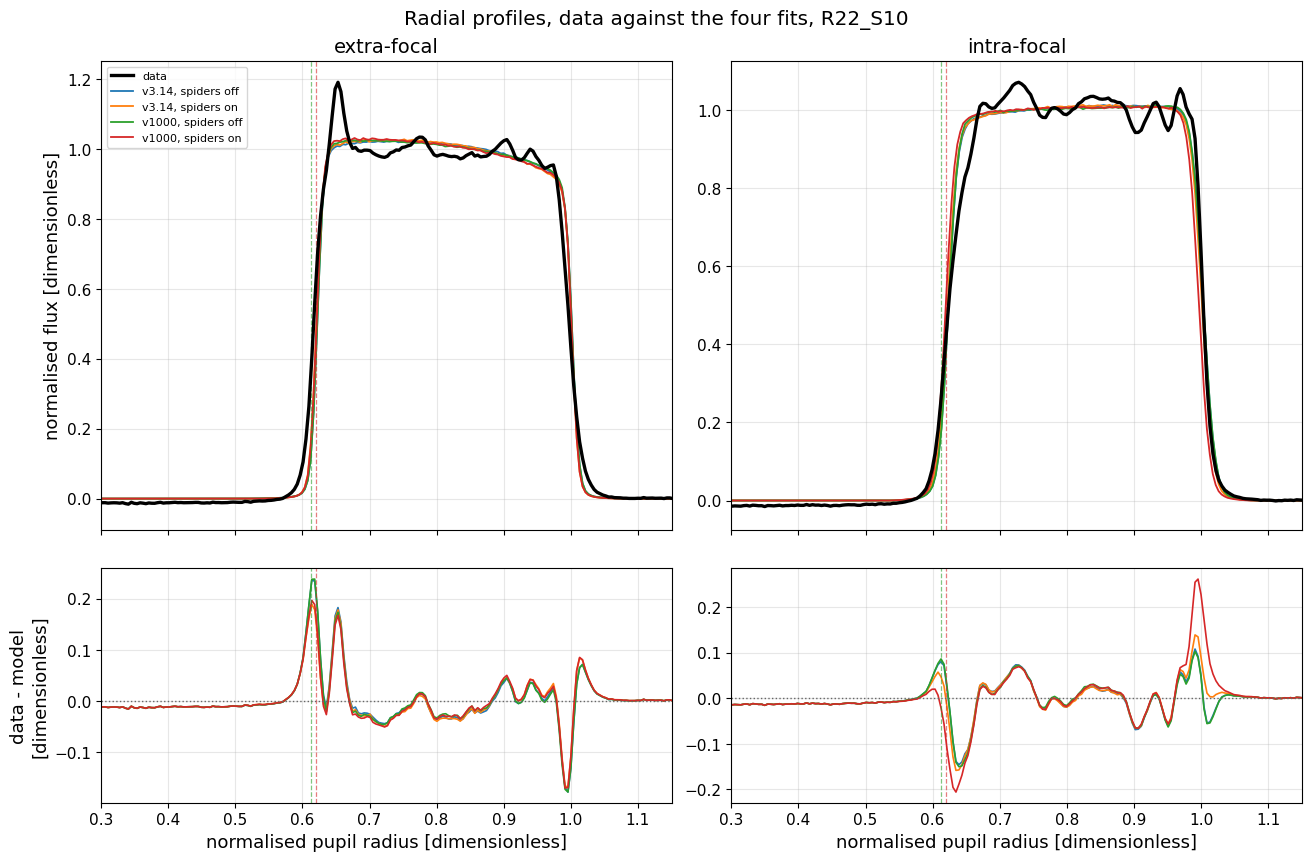

In [17]:
fit_radial = {}
for key, f in fits.items():
    r_pix, flux, flux_err, n_pix = rp.radial_profile(
        f["model_img"], n_bins=n_radial_bins)
    r_norm, flux_norm, r_edge_pix = rp.normalise_profile(r_pix, flux)
    fit_radial[key] = dict(r_norm=r_norm, flux_norm=flux_norm,
                           r_edge_pix=r_edge_pix)

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for col, side in enumerate(("extra", "intra")):
    ax_top, ax_bot = axes[0, col], axes[1, col]
    data = profiles[side]
    ax_top.plot(data["r_norm"], data["flux_norm"], lw=2.4, color="k",
                label="data", zorder=5)

    for n, (model_name, spiders) in enumerate(FIT_CONFIGS):
        prof = fit_radial[(model_name, spiders, side)]
        label = f"{model_name}, spiders {'on' if spiders else 'off'}"
        ax_top.plot(prof["r_norm"], prof["flux_norm"], lw=1.3, color=f"C{n}",
                    label=label)
        # Residual on the data's radius grid.
        model_on_data = np.interp(data["r_norm"], prof["r_norm"],
                                  prof["flux_norm"], left=np.nan, right=np.nan)
        ax_bot.plot(data["r_norm"], data["flux_norm"] - model_on_data, lw=1.2,
                    color=f"C{n}")

    for model_name, edge_norm in rp.INNER_EDGE_NORM.items():
        for ax in (ax_top, ax_bot):
            ax.axvline(edge_norm, ls="--", lw=0.9, alpha=0.6,
                       color="C2" if model_name == "v3.14" else "C3")
    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    ax_top.set_title(f"{side}-focal")
    ax_bot.set_xlabel("normalised pupil radius [dimensionless]")
    ax_bot.set_xlim(0.3, 1.15)
    if col == 0:
        ax_top.set_ylabel("normalised flux [dimensionless]")
        ax_bot.set_ylabel("data - model\n[dimensionless]")
        ax_top.legend(loc="upper left", fontsize=8)

fig.suptitle(f"Radial profiles, data against the four fits, {detector_name}")
fig.savefig(f"{output_dir}/radial_fits_{detector_name}.pdf", bbox_inches="tight")

print(f"{'model':7s} {'spiders':8s} {'side':>6s} {'nMAD resid':>12s}")
for model_name, spiders in FIT_CONFIGS:
    for side in ("extra", "intra"):
        data = profiles[side]
        prof = fit_radial[(model_name, spiders, side)]
        model_on_data = np.interp(data["r_norm"], prof["r_norm"],
                                  prof["flux_norm"], left=np.nan, right=np.nan)
        resid = data["flux_norm"] - model_on_data
        inside = np.isfinite(resid) & (data["r_norm"] > 0.65) & (data["r_norm"] < 0.95)
        nmad = 1.48 * np.nanmedian(np.abs(resid[inside] - np.nanmedian(resid[inside])))
        print(f"{model_name:7s} {'on' if spiders else 'off':8s} {side:>6s} "
              f"{nmad:>12.4f}")
print("\nnMAD of the data-minus-model normalised flux over the flat annulus "
      "0.65-0.95,\ndimensionless. Lower is a better radial match.")

### Fit overlays on the azimuthal profiles

Same comparison, azimuthally. This is where the spider models should show
up: with `modelSpiderShadows` off, the model has no vanes and cannot
reproduce the dips.

model   spiders    side   nMAD resid
v3.14   off       extra       0.0403
v3.14   off       intra       0.0362
v3.14   on        extra       0.0387
v3.14   on        intra       0.0356
v1000   off       extra       0.0402
v1000   off       intra       0.0343
v1000   on        extra       0.0381
v1000   on        intra       0.0353

nMAD of the data-minus-model normalised flux against azimuth, dimensionless.


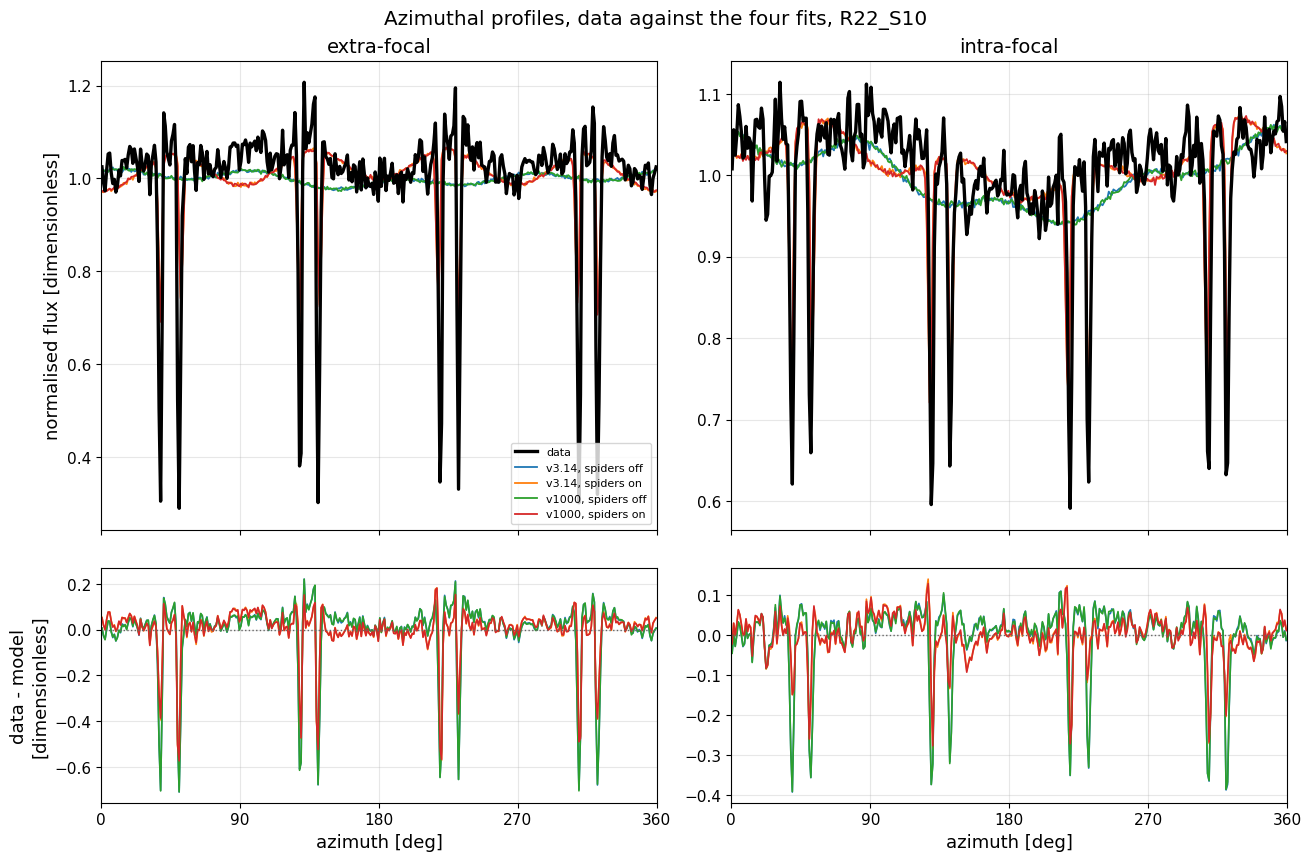

In [18]:
fit_azimuthal = {}
for key, f in fits.items():
    angle_deg, flux, flux_err, n_pix = rp.azimuthal_profile(
        f["model_img"], n_bins=n_azimuthal_bins, r_range_norm=azimuthal_annulus,
        r_edge_pix=fit_radial[key]["r_edge_pix"])
    fit_azimuthal[key] = dict(angle_deg=angle_deg,
                              flux_norm=flux / np.nanmean(flux))

fig, axes = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True,
                         gridspec_kw=dict(height_ratios=[2, 1], hspace=0.08))

for col, side in enumerate(("extra", "intra")):
    ax_top, ax_bot = axes[0, col], axes[1, col]
    data = azimuthal[side]
    ax_top.plot(data["angle_deg"], data["flux_norm"], lw=2.4, color="k",
                label="data", zorder=5)

    for n, (model_name, spiders) in enumerate(FIT_CONFIGS):
        prof = fit_azimuthal[(model_name, spiders, side)]
        label = f"{model_name}, spiders {'on' if spiders else 'off'}"
        ax_top.plot(prof["angle_deg"], prof["flux_norm"], lw=1.3, color=f"C{n}",
                    label=label)
        ax_bot.plot(data["angle_deg"], data["flux_norm"] - prof["flux_norm"],
                    lw=1.2, color=f"C{n}")

    ax_bot.axhline(0.0, ls=":", lw=1.0, color="0.4")
    ax_top.set_title(f"{side}-focal")
    ax_bot.set_xlabel("azimuth [deg]")
    ax_bot.set_xlim(0, 360)
    ax_bot.set_xticks(np.arange(0, 361, 90))
    if col == 0:
        ax_top.set_ylabel("normalised flux [dimensionless]")
        ax_bot.set_ylabel("data - model\n[dimensionless]")
        ax_top.legend(loc="lower right", fontsize=8)

fig.suptitle(f"Azimuthal profiles, data against the four fits, {detector_name}")
fig.savefig(f"{output_dir}/azimuthal_fits_{detector_name}.pdf",
            bbox_inches="tight")

print(f"{'model':7s} {'spiders':8s} {'side':>6s} {'nMAD resid':>12s}")
for model_name, spiders in FIT_CONFIGS:
    for side in ("extra", "intra"):
        resid = (azimuthal[side]["flux_norm"]
                 - fit_azimuthal[(model_name, spiders, side)]["flux_norm"])
        nmad = 1.48 * np.nanmedian(np.abs(resid - np.nanmedian(resid)))
        print(f"{model_name:7s} {'on' if spiders else 'off':8s} {side:>6s} "
              f"{nmad:>12.4f}")
print("\nnMAD of the data-minus-model normalised flux against azimuth, "
      "dimensionless.")

<a id='residuals'></a>
## Residual images

The profiles are projections, so each one hides whatever the other would show: a
radial average hides azimuthal structure and vice versa. These are the
two-dimensional data-minus-model residuals, which hide neither.

Rows are the four fit configurations, columns the two sides of focus. A diverging
colour scale centred on zero, shared across all panels, so panels are directly
comparable: red is data brighter than model, blue is model brighter than data.

colour scale +/-0.450 (dimensionless, fraction of the model's annulus level)
set to the 99th percentile of |residual| over all eight panels


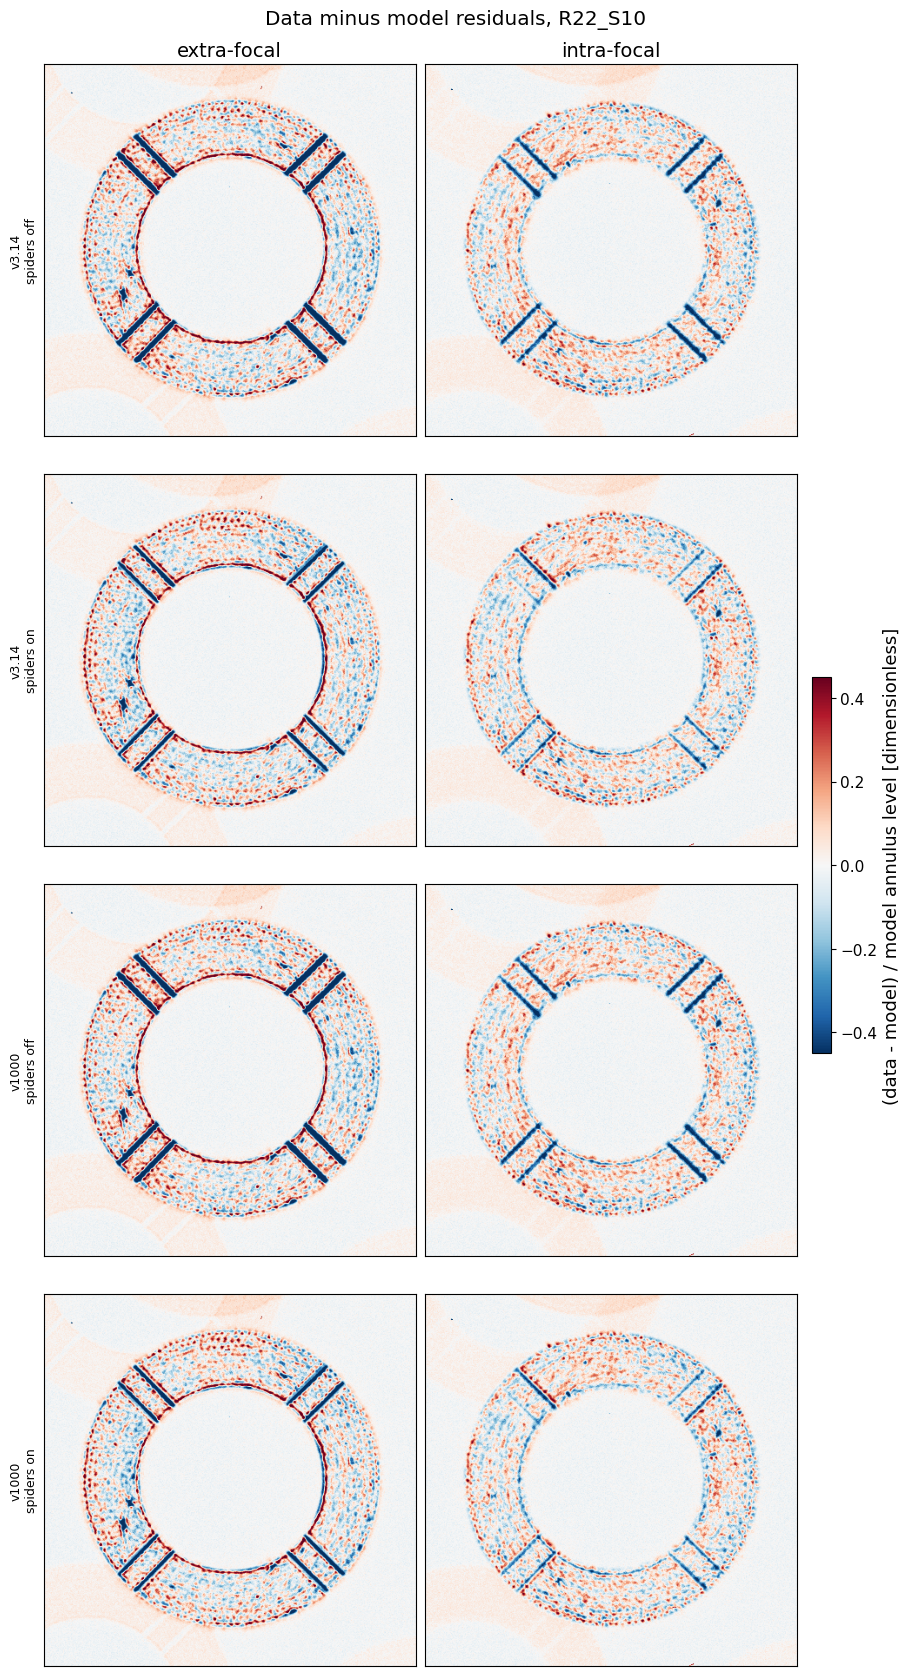

In [19]:
resid_images = {}
for key, f in fits.items():
    # Normalise by the model's annulus level so panels share one scale and the
    # residual reads as a fraction of the donut's own brightness.
    model = f["model_img"]
    scale = np.nanpercentile(model[model > 0], 75) if (model > 0).any() else 1.0
    resid_images[key] = (f["img"] - model) / scale

vlim = np.nanpercentile(np.abs(np.concatenate(
    [r.ravel() for r in resid_images.values()])), 99.0)
print(f"colour scale +/-{vlim:.3f} (dimensionless, fraction of the model's "
      f"annulus level)")
print("set to the 99th percentile of |residual| over all eight panels")

fig, axes = plt.subplots(len(FIT_CONFIGS), 2,
                         figsize=(9.0, 4.2 * len(FIT_CONFIGS)))
for row, (model_name, spiders) in enumerate(FIT_CONFIGS):
    for col, side in enumerate(("extra", "intra")):
        ax = axes[row, col]
        im = ax.imshow(resid_images[(model_name, spiders, side)],
                       origin="lower", cmap="RdBu_r", vmin=-vlim, vmax=+vlim)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"{side}-focal")
        if col == 0:
            ax.set_ylabel(f"{model_name}\nspiders {'on' if spiders else 'off'}",
                          fontsize=9)

fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02,
             label="(data - model) / model annulus level [dimensionless]")
fig.suptitle(f"Data minus model residuals, {detector_name}")
fig.savefig(f"{output_dir}/residual_images_{detector_name}.pdf",
            bbox_inches="tight")

In [20]:
# Where does the residual live? Split it by pupil zone, so the images above get
# a number. Signed mean shows a systematic push; nMAD shows unmodelled structure
# that averages out.
print(f"{'model':7s} {'spiders':8s} {'side':>6s} {'zone':>12s} "
      f"{'signed mean':>12s} {'nMAD':>9s}")
for model_name, spiders in FIT_CONFIGS:
    for side in ("extra", "intra"):
        resid = resid_images[(model_name, spiders, side)]
        ny, nx = resid.shape
        yy, xx = np.mgrid[0:ny, 0:nx]
        x0, y0 = rp.donut_centroid(fits[(model_name, spiders, side)]["model_img"])
        r = np.hypot(xx - x0, yy - y0) / fit_radial[(model_name, spiders, side)]["r_edge_pix"]
        for label, (lo, hi) in (("inner 0.62-0.70", (0.62, 0.70)),
                                ("flat 0.70-0.94", (0.70, 0.94)),
                                ("outer 0.94-1.00", (0.94, 1.00))):
            sel = np.isfinite(resid) & (r >= lo) & (r < hi)
            if not sel.any():
                continue
            v = resid[sel]
            nmad = 1.48 * np.median(np.abs(v - np.median(v)))
            print(f"{model_name:7s} {'on' if spiders else 'off':8s} {side:>6s} "
                  f"{label:>12s} {np.mean(v):>+12.4f} {nmad:>9.4f}")
print("\nBoth dimensionless, as a fraction of the model's annulus level.")

model   spiders    side         zone  signed mean      nMAD
v3.14   off       extra inner 0.62-0.70      +0.0467    0.1971
v3.14   off       extra flat 0.70-0.94      -0.0349    0.1285
v3.14   off       extra outer 0.94-1.00      -0.0026    0.1729
v3.14   off       intra inner 0.62-0.70      -0.0299    0.1412
v3.14   off       intra flat 0.70-0.94      -0.0031    0.1157
v3.14   off       intra outer 0.94-1.00      +0.0012    0.1500
v3.14   on        extra inner 0.62-0.70      +0.0394    0.1971
v3.14   on        extra flat 0.70-0.94      -0.0315    0.1221
v3.14   on        extra outer 0.94-1.00      +0.0058    0.1702
v3.14   on        intra inner 0.62-0.70      -0.0301    0.1320
v3.14   on        intra flat 0.70-0.94      -0.0026    0.1119
v3.14   on        intra outer 0.94-1.00      +0.0092    0.1489
v1000   off       extra inner 0.62-0.70      +0.0403    0.1956
v1000   off       extra flat 0.70-0.94      -0.0324    0.1275
v1000   off       extra outer 0.94-1.00      -0.0058    0.1735


<a id='interpretation'></a>
## Interpretation

**Measured on seq_num 337 (extra) and 340 (intra), R22_S10, field angle
(-0.263, -0.062) deg. Numbers below are this notebook's output.**

The donut diameters come out at 6.95 mm extra and 6.85 mm intra, against the
6.7 mm `wfs/` predicted for a 4 + 4 mm camera-plus-M2 split and 7.0 mm for
camera-only 8 mm. Both sit between the two predictions, nearer the camera-only
value, so the images do **not** cleanly discriminate the split on size alone --
the Trim remains the evidence for 4 + 4 mm. The bounding-box diameter is also an
overestimate of the illuminated outer edge, which the profile puts at 341.5 and
335.7 pixel, i.e. 6.83 and 6.71 mm across.

Josh's ring is present and it is extra-focal, with the flux balance reversing
between the two sides:

| zone (normalised radius) | extra | intra | extra - intra |
|---|---|---|---|
| inner ring, 0.62-0.70 | 1.0073 | 0.8532 | **+0.1541** |
| outer, 0.94-1.00 | 0.8803 | 0.9760 | **-0.0957** |

All dimensionless normalised flux, relative to the mean over the illuminated
annulus. The intra-minus-extra difference peaks at **-0.3330 (dimensionless) at
normalised radius 0.648**, just outside the inner pupil edge (0.612 in v3.14,
0.620 in v1000), and not at the rim.

**This favours an OPD term over a pupil-model error.** Flux moves toward the inner
edge extra-focally and toward the outer edge intra-focally, with the two zones
opposite in sign and comparable in size, so the total is conserved and
redistributed radially. A mask boundary error would move an edge *position* the
same way on both sides of focus rather than swapping the flux balance between
zones. The feature's location at the inner edge is consistent with a turned-down
edge on the inside of M1, which is where v1000 also moves the inner radius
(2.558 m to 2.5840 m, outward by 26.0 mm).

`ring_excess` is instructive about which pupil model fits the inner edge better.
Referenced to v1000's 0.6204 inner edge the extra-focal ring reads **+0.0132**;
referenced to v3.14's 0.6120 it reads **-0.0626**, i.e. the band lands partly in
the central hole. That is independent support for v1000's inner radius, from the
images rather than from a fit.

**Caveats, before this is taken as settled.**

- One donut per side, on one sensor, on one night. The item asks for a
  distribution; this is a single pair.
- The profile is azimuthally averaged, so a localised figure error would be
  diluted and an azimuthal analysis is the obvious next cut.
- The two donuts differ in outer edge by 5.8 pixel (0.06 mm), which the
  normalisation removes by construction; whether that size difference is itself
  part of the effect has not been separated.
- Converting the normalised-flux ring above into um of wavefront, so it can be
  compared directly against the 0.267 um of Z11 split the best fit leaves
  unexplained, is still to do.

## What the fits add

The 2x2 of pupil model against spider modelling separates two effects that turn
out to be **orthogonal**:

| | effect on Z11 split | effect on chi2/dof |
|---|---|---|
| pupil model, v3.14 to v1000 | +0.8037 to +0.3669 um wf, a 54 per cent cut | negligible |
| spiders, off to on | about -0.02 um wf | -19 per cent extra, -16 per cent intra |

So v1000 is the better pupil *geometry* for the Z11 diagnostic, and spiders are a
real image-fidelity gain that does not confound it. Step 6 of item 7 is answered:
spiders can be included with good fidelity, as a plain config toggle.

**The residual is not removed by either.** v1000 with spiders still leaves
+0.3511 um of wavefront against about 0.10 um from diffraction, and the radial
residual panels show the data-minus-model trace is largest near the inner edge in
every configuration. That is the same place the intra-minus-extra difference
peaks, and it is consistent with a residual OPD term rather than a mask error.

At the resolved 1 deg binning the azimuthal structure is much larger than it
looked at 5 deg: peak-to-peak is 0.9177 extra-focal against 0.5229 intra-focal,
and the intra-minus-extra difference peaks at +0.5219 at 140.5 deg against a
robust scatter of 0.0491 (all dimensionless). The extra-focal donut is
substantially more azimuthally structured than the intra one. Localising that to
a sector of M1 needs more than one donut pair.

## The residual images

The 2-D residuals make the sign flip a direct measurement rather than an
inference from two projections, and it is **identical in all four
configurations**:

| zone | extra, signed mean | intra, signed mean |
|---|---|---|
| inner 0.62-0.70 | +0.033 to +0.047 | -0.030 to -0.035 |
| flat 0.70-0.94 | -0.032 to -0.035 | -0.003 to -0.001 |
| outer 0.94-1.00 | -0.006 to +0.009 | -0.002 to +0.009 |

Dimensionless, as a fraction of the model's annulus level, ranges over the four
configurations. The inner zone is positive extra-focally and negative
intra-focally in every case, with the flat zone taking the compensating deficit
on the extra side. Neither the pupil model nor the spiders shifts this, which is
what makes it a residual OPD term and not a mask-geometry error.

The nMAD columns also show the residual is **largest in the inner and outer
zones and smallest in the flat middle** (about 0.19 and 0.17 against 0.12
extra-focally), so the forward model fails hardest at both pupil boundaries.

**The intra-focal blur sits on its 1.5 arcsec bound in all four configurations.**
Released to 5.0 arcsec it fits 1.509 arcsec and Z11 moves 0.0005 um, so the bound
is not distorting the wavefront -- but it is active, and the extra-focal blur
(0.98 to 1.02 arcsec) is consistently lower. An intra/extra blur asymmetry that
survives every pupil model is itself unexplained.
